<a href="https://colab.research.google.com/github/Rajkumarte115/Gold-Price-Forecasting-using-Machine-Learning/blob/main/Gold_Price_Forecasting_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from  sklearn.ensemble import RandomForestRegressor
from sklearn  import metrics

Data collection and Processing

In [ ]:
# loading the csv data to a pandas Data frame
gold_data = pd.read_csv('/content/gld_price_data.csv')

In [ ]:
#print the first five row in the dataframe
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [ ]:
# print the last five row of the data frame
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [ ]:
# number of rows and column
gold_data.shape

(2290, 6)

In [ ]:
# getting some basic information in the dat.
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [ ]:
# checking the number of missing values
gold_data.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [ ]:
# getting the statistical measures the data
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


correleation
1. Postive correleation
2. negative ''

In [ ]:
correlation = gold_data.drop('Date', axis=1).corr()

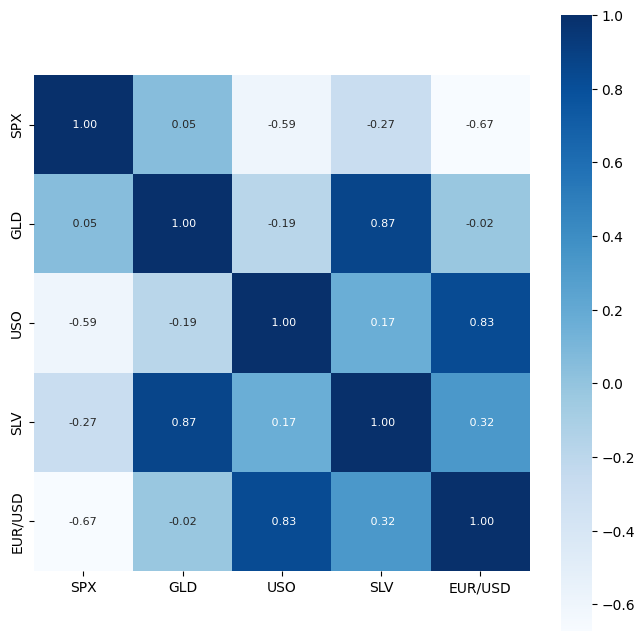

In [ ]:
# constructing a heatmap to understand the correlation.
plt.figure(figsize=(8,8))
sns.heatmap(correlation, cbar=True, square= True, fmt=' .2f', annot=True, annot_kws={'size':8}, cmap='Blues')
plt.show()

In [ ]:
# the correlation value of GLD
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


/tmp/ipython-input-2306502029.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'],color='yellow')


<Axes: xlabel='GLD', ylabel='Density'>

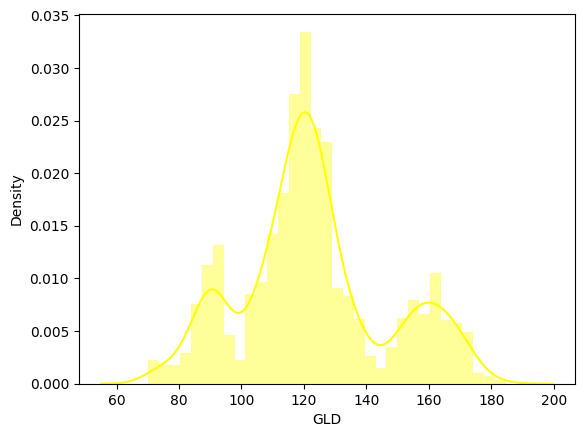

In [ ]:
#checkingnthe distribution of the gold price
sns.distplot(gold_data['GLD'],color='yellow')

In [ ]:
#spliting the features and target
x = gold_data.drop(['Date','GLD'], axis=1)
y = gold_data['GLD']

In [ ]:
print(x)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [ ]:
print(y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


spliting into training data and text the data

In [ ]:
x_train, x_test, y_train, y_text = train_test_split(x,y, test_size=0.2, random_state=2)

In [ ]:
# Model taing and randomforest regression model.
regessor = RandomForestRegressor(n_estimators=100)


In [ ]:
# training the model
regessor.fit(x_train,y_train)

RandomForestRegressor()

Model evaluation

In [ ]:
test_date_prediction = regessor.predict(x_test)

In [ ]:
print(test_date_prediction)

[168.26299915  82.06819969 115.89890002 127.63340098 120.56970169
 154.7172975  150.83529884 125.97300058 117.55469897 125.9560005
 116.86820087 171.61280107 141.72279818 167.74279856 115.14129987
 117.72210066 137.34550323 169.90770013 159.10780255 161.81819984
 155.08220024 125.32769997 176.20889902 156.85980349 125.12810017
  93.84219955  77.24910002 120.51890015 119.02949919 167.48799954
  88.11680038 125.20839988  91.15290054 117.63000069 121.03309954
 136.37370078 115.6142012  114.90770085 145.65830005 107.18160078
 104.69300242  87.15029792 126.39480068 117.82499992 153.20529927
 119.51110018 108.43639978 107.9910984   93.29330061 127.23029758
  75.32230038 113.73839927 121.34140048 111.27419938 118.81299897
 120.49509948 159.00640024 165.65380111 147.01759685  85.60739802
  94.41990039  86.73909862  90.52089997 118.98920102 126.48080085
 127.48740025 168.90049979 122.32309911 117.30289924  98.21679974
 167.8707019  142.99549812 131.95020192 121.19560247 121.3521995
 119.9948002

In [ ]:
# R squared error
error_score= metrics.r2_score(y_text, test_date_prediction)
print('R squared error : ', error_score)

R squared error :  0.9902929508628842


In [ ]:
# compare the actual value and predicated value in plot
y_text = list(y_text)


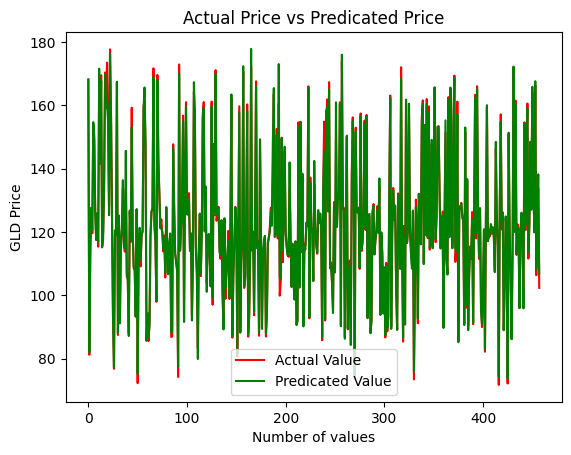

In [ ]:
plt.plot(y_text,color='red',label='Actual Value')
plt.plot(test_date_prediction, color='green',label='Predicated Value')
plt.title('Actual Price vs Predicated Price')
plt.xlabel('Number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()